<a href="https://colab.research.google.com/github/Linzhangcmingdan/vae_toy_case_moon/blob/main/Toycase__VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

In [ ]:
from google.colab import drive
import os
gdrive_path ='/content/gdrive/MyDrive/tu-delft'

#This will mount your google drive under "Mydrive"
drive.mount('/content/gdrive', force_remount=True)
#In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))

Mounted at /content/gdrive
['Medium_Understanding_Variational_Autoencoders (VAEs).ipynb', 'Toycase _VAE.ipynb', 'my_script.py']


In [ ]:
print("当前工作状态", os.getcwd())

当前工作状态 /content/gdrive/MyDrive/tu-delft


# try toy case

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler




## 1.生成 toycase数据

In [29]:
X, _ = make_moons(n_samples=1000, noise=0.1, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = torch.tensor(X, dtype=torch.float32)

# 2.定义 VAE 结构

In [90]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
       super(VAE, self).__init__()
          # 编码器
       self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
        )
       self.fc_mu = nn.Linear(128, latent_dim)
       self.fc_logvar = nn.Linear(128, latent_dim)
       # 解码器
       self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, input_dim),
        )


    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3.训练 VAE

# 4. VAE 总损失

### 最终的 VAE 损失函数：
$$
\mathcal{L} = \mathcal{L}_{\text{reconstruction}} + \mathcal{L}_{\text{KL}}
$$

即：
$$
\mathcal{L} = \sum_{i} (x_i - \hat{x}_i)^2 - \frac{1}{2} \sum_{i} (1 + \log\sigma^2 - \mu^2 - \sigma^2)
$$


In [100]:
input_dim = 2
latent_dim = 6
vae = VAE(input_dim, latent_dim)
optimizer = optim.AdamW(vae.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.8)  # 每 200 轮降低学习率


def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.09*kl_loss

epochs = 2000
for epoch in range(epochs):
    optimizer.zero_grad()
    recon_x, mu, logvar = vae(X)
    loss = loss_function(recon_x, X, mu, logvar)
    loss.backward()
    optimizer.step()
    scheduler.step()  # 更新学习率

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}， LR：{scheduler.get_last_lr()[0]:.6f}")

Epoch 0, Loss: 2244.8276， LR：0.005000
Epoch 100, Loss: 345.1161， LR：0.005000
Epoch 200, Loss: 329.8080， LR：0.004000
Epoch 300, Loss: 329.5268， LR：0.004000
Epoch 400, Loss: 330.6294， LR：0.003200
Epoch 500, Loss: 328.1269， LR：0.003200
Epoch 600, Loss: 316.7936， LR：0.002560
Epoch 700, Loss: 323.1241， LR：0.002560
Epoch 800, Loss: 326.4002， LR：0.002048
Epoch 900, Loss: 321.7271， LR：0.002048
Epoch 1000, Loss: 321.7863， LR：0.001638
Epoch 1100, Loss: 325.3860， LR：0.001638
Epoch 1200, Loss: 321.5898， LR：0.001311
Epoch 1300, Loss: 322.4496， LR：0.001311
Epoch 1400, Loss: 322.5544， LR：0.001049
Epoch 1500, Loss: 329.5500， LR：0.001049
Epoch 1600, Loss: 319.5383， LR：0.000839
Epoch 1700, Loss: 326.6156， LR：0.000839
Epoch 1800, Loss: 329.7285， LR：0.000671
Epoch 1900, Loss: 316.9544， LR：0.000671


# 补充说明 VAE 的目标

VAE 训练的目标是**最大化变分下界（ELBO，Evidence Lower Bound）**，等价于**最小化损失**：

$$
\mathcal{L} = \mathbb{E}_{q(z|x)} [\log p(x|z)] - D_{KL} (q(z|x) || p(z))
$$

其中：
- **第一项**：重构损失，衡量 $x$ 与 **VAE** 生成的 $x'$ 之间的误差。
- **第二项**：KL 散度，衡量 $q(z|x)$ 和 $p(z)$（标准正态分布）的差异。

由于我们是**最小化损失**，所以**负的 ELBO 就是 VAE 的损失函数**：

$$
\mathcal{L} = \mathcal{L}_{\text{reconstruction}} + \mathcal{L}_{\text{KL}}
$$


# 4.生成新数据

In [101]:
with torch.no_grad():
  z = torch.randn(1500, latent_dim)
  generated_data = vae.decode(z).numpy()
  generated_data = scaler.inverse_transform(generated_data)

# 5.可视化结果

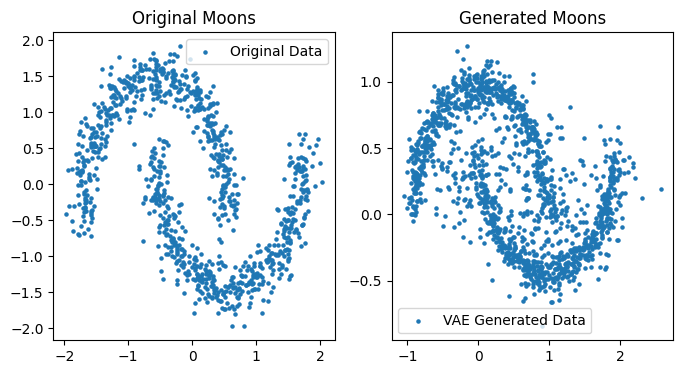

In [102]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:, 1], s=5, label='Original Data')
plt.legend()
plt.title('Original Moons')

plt.subplot(1, 2, 2)
plt.scatter(generated_data[:, 0], generated_data[:, 1], s=5, label='VAE Generated Data')
plt.legend()
plt.title('Generated Moons')

plt.show()


In [ ]:
%%writefile main_vae.py
import tools_vae as tvae
import torch
import vae_models as mds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# train the model
while True:
    scaler = tvae.train_models(
                    input_dim = 48,
                    hidden_dim = 10,
                    path_data =  r'/home/wxia/researchdrive/paper1/cleaned_data/uk_data_agg.csv',
                    saving_path =  r'/home/wxia/researchdrive/paper1/Models/models_agg/vae/uk_agg',
                    lr = 0.0002,
                    batch_size = 64,
                    epochs = 1,
                    save_control = True,
                    model_typle = '30m',
                    )
    break

# load the model
ganpath = r'uk_agg/models/30m_0.007_837_20230719-111510.pt'
vae = mds.VAE_30m(48, 10)
vae.load_state_dict(torch.load(ganpath))

# original data
path_data = r'/home/wxia/researchdrive/paper1/cleaned_data/uk_data_agg.csv'
or_data = np.array(pd.read_csv(path_data))
gen_data = vae.decode(torch.rand(or_data.shape[0], 10)).detach().numpy()
gen_data = scaler.inverse_transform(gen_data)

for i in range(or_data.shape[0]):
    plt.plot(or_data[i,:], c='r', alpha=0.1)
    plt.plot(gen_data[i,:], c='b', alpha=0.1)
plt.plot(or_data[i,:], c='r', alpha=0.1, label='original')
plt.plot(gen_data[i,:], c='b', alpha=0.1, label='generated')
plt.legend()
plt.show()

# save the generated data
save_path = r'/home/wxia/researchdrive/paper1/generated_data'
if not os.path.exists(save_path):
    os.makedirs(save_path)

pd.DataFrame(gen_data).to_csv(save_path + '/uk_data_agg_vae.csv', index=False)

Writing main_vae.py


In [ ]:
!python my_script.py


Hello from Colab!


In [ ]:
%%writefile models/vae/tools_vae.py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import vae_models as mds
import os
import datetime


class MyDataset(Dataset):
    """ Define the dataset """
    def __init__(self, numpy_array, range=(-0.98, 0.98)):
        self.scaler = MinMaxScaler(feature_range=range)
        scaled_data = self.scaler.fit_transform(numpy_array)
        self.data = torch.from_numpy(scaled_data).float()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return sample

    def inverse_transform(self, scaled_data):
        # Convert back to original scale
        original_scale_data = self.scaler.inverse_transform(scaled_data)
        return original_scale_data


def dataloader(data_set, batch_size=2, shuffle=True):
    """Define the dataloader"""
    dataset = MyDataset(data_set)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader, dataset

def loss_function_vae(recon_x, x, mu, logvar):
    """Define the loss function of vae"""
    mse = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld, mse, kld


def train_models(
    input_dim = 48,
    hidden_dim = 10,
    path_data =  r'/home/wxia/researchdrive/paper1/cleaned_data/uk_data_agg.csv',
    saving_path =  r'/home/wxia/researchdrive/paper1/Models/models_agg/vae/uk_agg',
    lr = 0.0002,
    batch_size = 64,
    epochs = 400,
    save_control = False,
    model_typle = '30m',
    ):

    """
    This the the training function of the model
    z_dim: The dimension of noise
    model_typle: model typles related to resoultion of the data we have 15 minutes (15m), 30m, and 60m
    lr: learning rate
    epochs: epochs
    k: training ratio (train discriminator once, then train generator 5 times)
    path_data: path of input data
    saving_path: path to save the data and model
    save_control: save the model or not
    """

    # load the data & data loader
    data = pd.read_csv(path_data)
    data_loader, scaler = dataloader(data, batch_size=batch_size, shuffle=True)

    # define the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # define the model
    if model_typle == '30m':
        vae = mds.VAE_30m(input_shape=input_dim, latent_dim=hidden_dim).to(device)
    elif model_typle == '60m':
        vae = mds.VAE_60m(input_shape=input_dim, latent_dim=hidden_dim).to(device)
    vae = nn.DataParallel(vae)

    # define the optimizer
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

    # store the loss
    losses = []
    msees = []
    klds = []

    # train the model
    print('Start training the model!')
    for epoch in range(epochs):
        print(f'Epoch [{epoch+1}/{epochs}]')
        for i, data in enumerate(data_loader):
            # renconstruct the data
            recon_data, mu, logvar = vae(data.to(device))

            # compute the loss
            loss, mse_l, kld_l = loss_function_vae(recon_data, data.to(device), mu, logvar)

            #optimize the model
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            msees.append(mse_l.item())
            klds.append(kld_l.item())

            # compute the js divergence
            p = data.cpu().detach().numpy()
            q = recon_data.cpu().detach().numpy()

            if save_control:
                print('saving the models')
                time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
                path = saving_path+f'/models'
                if not os.path.exists(path):
                    os.makedirs(path)
                torch.save(vae.module.state_dict(), path+f'/{model_typle}__{epoch}_{time}.pt')

    return scaler



Writing models/vae/tools_vae.py


In [ ]:
%%writefile models/vae/vae_models.py
import torch
from torch import nn

class VAE_30m(nn.Module):
    def __init__(self, input_shape=48, latent_dim=10):
        super(VAE_30m, self).__init__()

        self.input_shape = input_shape
        self.latent_dim = latent_dim
        self.out_scale1 = 12 # control the model complexity

        self.encoder = nn.Sequential(
                # First layer
                nn.Linear(self.input_shape,self.out_scale1*10),
                nn.BatchNorm1d(self.out_scale1*10),
                nn.LeakyReLU(),

                # second layer
                nn.Linear(self.out_scale1*10,self.out_scale1*5),
                nn.BatchNorm1d(self.out_scale1*5),
                nn.LeakyReLU(),
                )

        self.mu = nn.Linear(self.out_scale1*5, self.latent_dim)
        self.logvar = nn.Linear(self.out_scale1*5, self.latent_dim)

        self.decoder = nn.Sequential(
                # First layer
                nn.Linear(self.latent_dim,self.out_scale1*5),
                nn.BatchNorm1d(self.out_scale1*5),
                nn.LeakyReLU(),

                # second layer
                nn.Linear(self.out_scale1*5,self.out_scale1*10),
                nn.BatchNorm1d(self.out_scale1*10),
                nn.LeakyReLU(),

                # third layer
                nn.Linear(self.out_scale1*10,self.input_shape),
                nn.BatchNorm1d(self.input_shape),
                nn.Tanh()
            )


    def encode(self, x):
        out = self.encoder(x)
        return self.mu(out), self.logvar(out)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# class VAE_60m(nn.Module):
#     def __init__(self, input_shape=24, latent_dim=5):
#         super(VAE_60m, self).__init__()

#         self.input_shape = input_shape
#         self.latent_dim = latent_dim
#         self.out_scale1 = 6 # control the model complexity

#         self.encoder = nn.Sequential(
#                 # First layer
#                 nn.Linear(self.input_shape,self.out_scale1*10),
#                 nn.BatchNorm1d(self.out_scale1*10),
#                 nn.LeakyReLU(),

#                 # second layer
#                 nn.Linear(self.out_scale1*10,self.out_scale1*5),
#                 nn.BatchNorm1d(self.out_scale1*5),
#                 nn.LeakyReLU(),
#                 )

#         self.mu = nn.Linear(self.out_scale1*5, self.latent_dim)
#         self.logvar = nn.Linear(self.out_scale1*5, self.latent_dim)

#         self.decoder = nn.Sequential(
#                 # First layer
#                 nn.Linear(self.latent_dim,self.out_scale1*5),
#                 nn.BatchNorm1d(self.out_scale1*5),
#                 nn.LeakyReLU(),

#                 # second layer
#                 nn.Linear(self.out_scale1*5,self.out_scale1*10),
#                 nn.BatchNorm1d(self.out_scale1*10),
#                 nn.LeakyReLU(),

#                 # third layer
#                 nn.Linear(self.out_scale1*10,self.input_shape),
#                 nn.BatchNorm1d(self.input_shape),
#                 nn.Tanh()
#             )


#     def encode(self, x):
#         out = self.encoder(x)
#         return self.mu(out), self.logvar(out)

#     def reparameterize(self, mu, logvar):
#         std = torch.exp(0.5*logvar)
#         eps = torch.randn_like(std)
#         return mu + eps*std

#     def decode(self, z):
#         return self.decoder(z)

#     def forward(self, x):
#         mu, logvar = self.encode(x)
#         z = self.reparameterize(mu, logvar)
#         return self.decode(z), mu, logvar


Writing models/vae/vae_models.py
